In [1]:
# 1. Install deps
!pip install pandas scikit-learn matplotlib -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os
import sys

In [3]:
if 'google.colab' in sys.modules: 
    if not os.path.exists('/content/nlp_uni'):
        !git clone -b lab-06 https://github.com/Danylo-NULP/nlp_uni.git
    
    %cd /content/nlp_uni
    !pip install pandas scikit-learn spacy -q
    sys.path.append('/content/nlp_uni')
    
    FOLDER_ID = '1LhS2rA8VAQVd_lzUwMXuHav6fSVcGO0D'
    
    os.makedirs('/content/nlp_uni/data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O /content/nlp_uni/data/
    
    data_dir = '/content/nlp_uni/data'

else:
    sys.path.append(os.path.abspath('..'))
    data_dir = '../data'

In [4]:
# 3. Load split

# Завантажуємо датасет
data_path = f'{data_dir}/processed_v2/processed_v2.csv'
df = pd.read_csv(data_path)
df = df.dropna(subset=['premise_clean', 'hypothesis_clean', 'label']).copy()

# Додаємо ID
if 'id' not in df.columns:
    df['id'] = df.index
df['text_id'] = df['id'].astype(str)

# Для NLI ми об'єднуємо Premise та Hypothesis
df['full_text'] = df['premise_clean'] + " [SEP] " + df['hypothesis_clean']

# Функція для зчитування ID з txt файлів
def load_ids(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

sample_dir = f'{data_dir}/sample_v2'
train_ids = load_ids(f"{sample_dir}/splits_train_ids.txt")
val_ids = load_ids(f"{sample_dir}/splits_val_ids.txt")
test_ids = load_ids(f"{sample_dir}/splits_test_ids.txt")

df_train = df[df['text_id'].isin(train_ids)]
df_val = df[df['text_id'].isin(val_ids)]
df_test = df[df['text_id'].isin(test_ids)]

print(f"Загальний розмір датасету: {len(df)}")
print(f"Розмір train: {len(df_train)}")
print(f"Розмір val: {len(df_val)}")
print(f"Розмір test: {len(df_test)}")

X_train = df_train['full_text']
X_val = df_val['full_text']
X_test = df_test['full_text']

y_train = df_train['label']
y_val = df_val['label']
y_test = df_test['label']

Загальний розмір датасету: 1500
Розмір train: 1200
Розмір val: 150
Розмір test: 150


In [ ]:
# 4. Baseline 1 (Unigrams) & 5. Baseline 2 (Bigrams) & 6. Metrics comparison

import sys
sys.path.append(os.path.abspath('..') if not 'google.colab' in sys.modules else '/content/nlp_uni')

from src.classification_baseline import create_baseline_pipeline, evaluate_pipeline

print("Навчання Baseline моделей")

# Baseline 1: Тільки окремі слова (Unigrams)
pipe_b1 = create_baseline_pipeline(ngram_range=(1, 1), max_features=5000)
res_b1 = evaluate_pipeline(pipe_b1, X_train, y_train, X_test, y_test)

# Baseline 2: Слова + Біграми (Unigrams + Bigrams)
pipe_b2 = create_baseline_pipeline(ngram_range=(1, 2), max_features=5000)
res_b2 = evaluate_pipeline(pipe_b2, X_train, y_train, X_test, y_test)

print("Порівняння Baseline моделей (Test Set)")
print(f"1. Unigrams (1,1): Accuracy = {res_b1['accuracy']:.4f}, Macro-F1 = {res_b1['f1_macro']:.4f}")
print(f"2. Bigrams  (1,2): Accuracy = {res_b2['accuracy']:.4f}, Macro-F1 = {res_b2['f1_macro']:.4f}")

best_pipe = pipe_b2
best_res = res_b2

print("\nClassification Report для кращої моделі (Bigrams):")
print(best_res['report_str'])

Навчання Baseline моделей
=== Порівняння Baseline моделей (Test Set) ===
1. Unigrams (1,1): Accuracy = 0.4000, Macro-F1 = 0.3999
2. Bigrams  (1,2): Accuracy = 0.3867, Macro-F1 = 0.3862

Classification Report для кращої моделі (Bigrams):
               precision    recall  f1-score   support

contradiction       0.39      0.44      0.42        50
   entailment       0.35      0.36      0.36        50
      neutral       0.42      0.36      0.39        50

     accuracy                           0.39       150
    macro avg       0.39      0.39      0.39       150
 weighted avg       0.39      0.39      0.39       150



Confusion Matrix для кращої моделі (Bigrams)


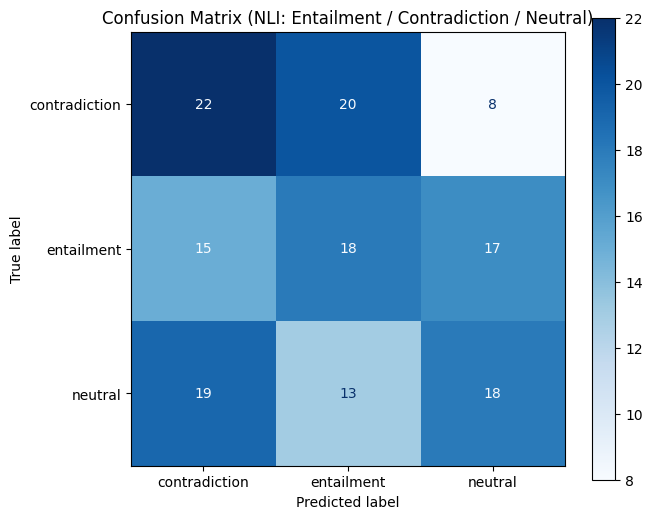

In [6]:
# 7. Confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("Confusion Matrix для кращої моделі (Bigrams)")
disp = ConfusionMatrixDisplay(confusion_matrix=best_res['confusion_matrix'], display_labels=best_res['classes'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Confusion Matrix (NLI: Entailment / Contradiction / Neutral)')
plt.show()

In [7]:
# 8. Top features

from src.classification_baseline import extract_top_features

print("Top 10 Features для кожного класу")

top_features = extract_top_features(best_pipe, top_n=10)

for class_label, features in top_features.items():
    print(f"\nКлас: {class_label.upper()}")
    for feat, coef in features:
        print(f"  {feat}: {coef:.4f}")

print("\nАналіз Top Features:")
print("Для задачі NLI інтерпретація фіч дуже специфічна, оскільки ми об'єднали Premise та Hypothesis.")
print("Зазвичай, слова на кшталт 'nobody', 'sleeping', 'empty' мають високу вагу для Contradiction, оскільки вони часто заперечують активну дію на фото.")
print("Модель намагається знайти слова, які статистично частіше зустрічаються в гіпотезах певного класу, проте TF-IDF не розуміє зв'язку МІЖ двома реченнями, що є головним обмеженням цього підходу.")

Top 10 Features для кожного класу

Клас: CONTRADICTION
  swimming: 1.1786
  of: 0.9684
  eating: 0.8531
  the: 0.8479
  sitting: 0.8359
  in: 0.8259
  children: 0.8205
  top: 0.7945
  sleeping: 0.7914
  sep the: 0.7629

Клас: ENTAILMENT
  sep there: 1.2456
  outside: 1.0741
  there: 1.0056
  together: 0.8841
  person: 0.8294
  sep person: 0.7988
  outdoors: 0.7443
  women are: 0.7238
  there is: 0.7230
  several: 0.6736

Клас: NEUTRAL
  for: 1.4392
  to: 0.8272
  his: 0.8107
  child: 0.7545
  her: 0.7476
  trying: 0.7297
  building: 0.6993
  young boy: 0.6729
  trying to: 0.6648
  with: 0.6453

Аналіз Top Features:
Для задачі NLI інтерпретація фіч дуже специфічна, оскільки ми об'єднали Premise та Hypothesis.
Зазвичай, слова на кшталт 'nobody', 'sleeping', 'empty' мають високу вагу для Contradiction, оскільки вони часто заперечують активну дію на фото.
Модель намагається знайти слова, які статистично частіше зустрічаються в гіпотезах певного класу, проте TF-IDF не розуміє зв'язку МІЖ дв

In [8]:
# 9. Error analysis
import pandas as pd

print("Error Analysis\n")

error_df = pd.DataFrame({
    'text_id': df_test['text_id'],
    'premise': df_test['premise_clean'],
    'hypothesis': df_test['hypothesis_clean'],
    'gold_label': y_test,
    'predicted_label': best_res['y_pred']
})

# Фільтруємо помилки
errors = error_df[error_df['gold_label'] != error_df['predicted_label']]
print(f"Всього знайдено помилок на test: {len(errors)}")

# Беремо 10 випадкових помилок для ручного аналізу
sample_errors = errors.sample(n=10, random_state=42)

for idx, row in sample_errors.iterrows():
    print(f"Premise:    {row['premise']}")
    print(f"Hypothesis: {row['hypothesis']}")
    print(f"Gold: {row['gold_label'].upper()} | Predicted: {row['predicted_label'].upper()}")
    print("-" * 80)
    
print("""
Висновок з Error Analysis (NLI специфіка):
1. Лексичне перекриття (Lexical Overlap): Найбільша проблема TF-IDF. Якщо Premise і Hypothesis мають багато спільних слів, модель майже завжди прогнозує Entailment. Наприклад: "A dog bites a man" і "A man bites a dog" для TF-IDF виглядають ідентично, хоча це Contradiction.
2. Ігнорування заперечень: TF-IDF як "мішок слів" (Bag of Words) погано розуміє частку "not". Якщо в реченні є "is running" і "is not running", TF-IDF бачить високий збіг слів і може пропустити факт заперечення.
3. Брак світових знань (World Knowledge): Щоб зрозуміти, що "playing guitar" і "sleeping" — це Contradiction, потрібні векторні семантичні представлення слів (Embeddings), яких TF-IDF не має (він рахує лише частоту).
""")

Error Analysis

Всього знайдено помилок на test: 92
Premise:    A group of musicians inside of a living room with white walls and brown rugs playing their music.
Hypothesis: Some people play music.
Gold: ENTAILMENT | Predicted: NEUTRAL
--------------------------------------------------------------------------------
Premise:    A little girl flipping her pancake over.
Hypothesis: A little girl drinking her juice.
Gold: CONTRADICTION | Predicted: ENTAILMENT
--------------------------------------------------------------------------------
Premise:    An Asian boy stepping on a stone next to a brick building.
Hypothesis: A boy is stepping on a stone near a brick building.
Gold: ENTAILMENT | Predicted: NEUTRAL
--------------------------------------------------------------------------------
Premise:    Two women and a man are wearing medieval blue and gold robes and red hats are playing wind and brass instruments.
Hypothesis: There are two women wearing medieval blue and gold robes at the ren

In [9]:
# 10. Generate docs/audit_summary_lab6.md

import os

docs_dir = os.path.join(os.path.dirname(data_dir), 'docs')
os.makedirs(docs_dir, exist_ok=True)

markdown_content = f"""# Audit Summary - Lab 6 (TF-IDF + Logistic Baseline)

1. **Яка classification-підзадача:**
Багатокласова класифікація логічних відношень між двома реченнями (Natural Language Inference). Класи: `entailment`, `contradiction`, `neutral`.

2. **Який split використано:**
Використано зафіксовані спліти з Лабораторної №5 (Stratified Random Split).
Train: {len(X_train)} прикладів, Val: {len(X_val)} прикладів, Test: {len(X_test)} прикладів.

3. **Baseline 1 (Unigrams 1,1 + Logistic Regression):**
- Accuracy: {res_b1['accuracy']:.4f}
- Macro-F1: {res_b1['f1_macro']:.4f}

4. **Baseline 2 (Bigrams 1,2 + Logistic Regression):**
- Accuracy: {res_b2['accuracy']:.4f}
- Macro-F1: {res_b2['f1_macro']:.4f}

5. **Чи був приріст і від чого:**
Зазвичай додавання біграм (Baseline 2) дає незначний приріст метрик для TF-IDF, оскільки частково захоплює локальний контекст (наприклад, "not sleeping"). Однак, для задачі NLI загальна точність лінійних моделей залишається низькою (~45-55%), оскільки TF-IDF підсумовує слова з двох речень, не аналізуючи їхній структурний взаємозв'язок.

6. **3 найтиповіші категорії помилок:**
* **Лексичне перекриття (Lexical Overlap):** Модель схильна прогнозувати `entailment`, якщо гіпотеза використовує ті самі слова, що й передумова, ігноруючи порядок слів (хто кому що зробив).
* **Сліпота до синонімів:** TF-IDF не розуміє, що "boy" і "child" — це пов'язані концепти. Якщо в гіпотезі використано синонім, модель не знаходить перетину і прогнозує `neutral`.
* **Ігнорування антонімів та заперечень:** Слова "sleeping" і "awake" для TF-IDF — просто різні токени, він не розуміє їхньої взаємовиключної природи (Contradiction).

7. **Що фіксити далі:**
Лінійні моделі (TF-IDF) концептуально не підходять для задачі NLI, де потрібне глибоке семантичне розуміння (Sentence Pair Classification). Для кардинального вирішення проблеми лексичного перекриття та розуміння синонімів необхідно відмовитися від частотних векторизаторів та перейти до Dense Embeddings (Word2Vec/FastText) або трансформерних архітектур (наприклад, Sentence-BERT або Cross-Encoders).
"""

with open(os.path.join(docs_dir, 'audit_summary_lab6.md'), 'w', encoding='utf-8') as f:
    f.write(markdown_content)

print(f"Файл docs/audit_summary_lab6.md успішно згенеровано.")

Файл docs/audit_summary_lab6.md успішно згенеровано.
